<a href="https://colab.research.google.com/github/zhappo/data-analyst-portfolio/blob/main/semana_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Análise de Dados da Semana #1: Vendas no Dataset Superstore!

**Pergunta de negócio:** Quais categorias lideram vendas na região Oeste, e como evoluem por ano?

**Dataset:** Superstore Sales (Kaggle/GitHub, 9.994 linhas reais de transações 2014-2017).

**Link:** https://raw.githubusercontent.com/yajasarora/Superstore-Sales-Analysis-with-Tableau/master/Superstore%20sales%20dataset.csv

**Ferramentas:** Python (Pandas + Matplotlib/Seaborn). Código completo abaixo!

## **Passos executados:**
1. Carreguegamento do CSV;
2. Limpeza;
3. Análise Exploratória;
4. Visualizações;
5. Conclusões.

## **Notas**

Pensando numa equipe multinacional, decidi por utilizar e padronizar usando as variaveos em inglês


# 1.Carregamento dos dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/yajasarora/Superstore-Sales-Analysis-with-Tableau/master/Superstore%20sales%20dataset.csv'
df = pd.read_csv(url,
                 encoding='latin1',
                 parse_dates=['Order Date', 'Ship Date'],
                 dayfirst=True)

## Verificações básicas

In [2]:
#@title Verificação do formato do dataset
print("Forma:", df.shape)

Forma: (9994, 21)


In [3]:
#@title Preview de sua estrutura (cabeçalho)
df.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
#@title Tipos e nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ï»¿Row ID      9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# 2.Limpeza


## 2.1 Recorte
Normalmente o processo de limpeza é realizado no conjunto, mas neste projeto iremos primeiro fazer o recorte, filtano os dados relativs a região Oeste (west) criando um dataset totalmene independente. E depois trabalharemos limepeza,ETA e Vizualizações sobre esse novo dataset.


In [5]:
# Criando um recorte totalmente independente com dados da região oeste (west).
df_west = df[df['Region'] == 'West'].copy(deep=True)

## 2.2 Limpeza

In [6]:
#Vamos limpar esse nosso recorte
df_west.drop_duplicates(inplace=True)  # Como vimos que existem, removemos  duplicatas.
df_west.dropna(subset=['Sales', 'Category'], inplace=True)  # Vimos que não há NaN, mas é boa prática
df_west['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')  #Vimos que já é númerico (float64), usamos aqui só para ilustrar caso não o fosse.



## 2.3 Reverificação
Então vamos olhar novamente, algumas caracteristicas do dataset que vamos trabalhar.

In [7]:
df_west.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3203 entries, 2 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ï»¿Row ID      3203 non-null   int64         
 1   Order ID       3203 non-null   object        
 2   Order Date     3203 non-null   datetime64[ns]
 3   Ship Date      3203 non-null   datetime64[ns]
 4   Ship Mode      3203 non-null   object        
 5   Customer ID    3203 non-null   object        
 6   Customer Name  3203 non-null   object        
 7   Segment        3203 non-null   object        
 8   Country        3203 non-null   object        
 9   City           3203 non-null   object        
 10  State          3203 non-null   object        
 11  Postal Code    3203 non-null   int64         
 12  Region         3203 non-null   object        
 13  Product ID     3203 non-null   object        
 14  Category       3203 non-null   object        
 15  Sub-Category   3203 non-nu

In [8]:
df_west.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825


In [16]:
#Ovservamos que os indices estão bagunçados, vamos corrigir para deoxar organizado

df_west.reset_index(drop=True, inplace=True)
df_west.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714,2016
1,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694,2014
2,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656,2014
3,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152,2014
4,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825,2014


# 3.Análise Exploratória

In [21]:
#@title Vendas por Categoria
sales_by_category = df_west.groupby('Category')['Sales'].agg(['sum', 'mean', 'count']).round(2)
sales_by_category

,sum,mean,count
Category,,,
Furniture,252612.74,357.30,707
Office Supplies,220853.25,116.42,1897
Technology,251991.83,420.69,599


In [22]:
#@title Evolução temporal
df_west['Order Date'] = pd.to_datetime(df['Order Date'])
df_west['Year'] = df['Order Date'].dt.year
sales_evolution = df_west.groupby(['Year', 'Category'])['Sales'].sum().unstack().round(2)
sales_evolution

Category,Furniture,Office Supplies,Technology
Year,,,
2014,54057.35,46466.28,43460.18
2015,53527.52,52173.30,44161.56
2016,76361.08,54374.90,89455.71
2017,68666.80,67838.76,74914.39


In [25]:
# Top Sub-Categorias (ex.: calçado, eletrônicos)
top_subcat = df.groupby('Sub-Category')['Sales'].sum().nlargest(5)
print("Top 5 Sub-Categorias:\n")
top_subcat


Top 5 Sub-Categorias:



,Sales
Sub-Category,
Phones,330007.054
Chairs,328449.103
Storage,223843.608
Tables,206965.532
Binders,203412.733


## 4.Visualizações

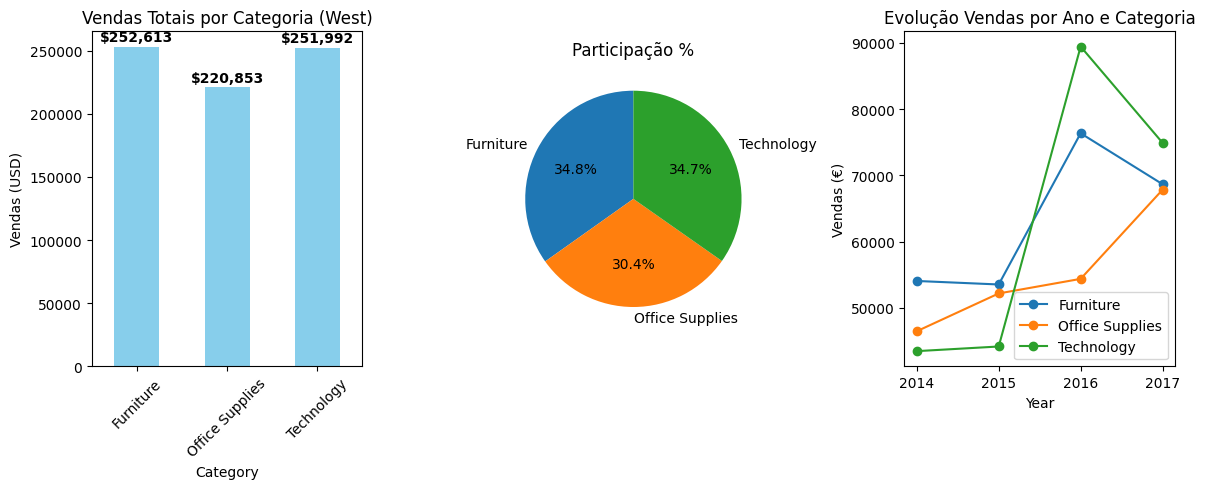

In [51]:
plt.style.use('default')
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))


# Gráfico 1: Barras com VALORES nas barras
sales_by_category['sum'].plot(kind='bar', ax=axs[0], color='skyblue')
axs[0].set_title('Vendas Totais por Categoria (West)')
axs[0].set_ylabel('Vendas (USD)')
axs[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(sales_by_category['sum']):
    axs[0].text(i, v + v*0.01, f'${v:,.0f}',  # Posição: acima da barra +1%
                ha='center', va='bottom', fontweight='bold', fontsize=10)


# Gráfico 2: Pizza %
axs[1].pie(sales_by_category['sum'], labels=sales_by_category.index,
           autopct='%1.1f%%', startangle=90)
axs[1].set_title('Participação %')


# Gráfico 3: Linha - Evolução Anual
sales_evolution.plot(kind='line', ax=axs[2], marker='o')
axs[2].set_title('Evolução Vendas por Ano e Categoria')
axs[2].set_ylabel('Vendas (€)')
axs[2].legend()
plt.tight_layout()
plt.show()


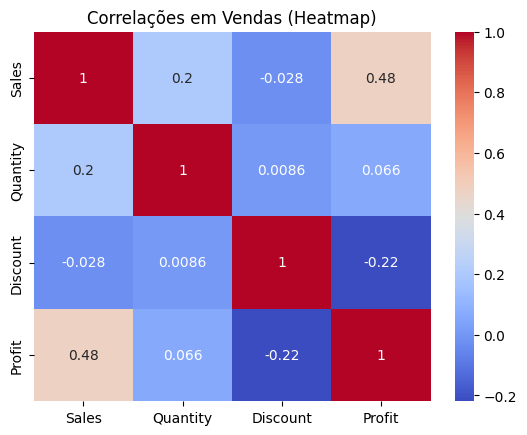

In [43]:
# Seaborn Heatmap correlações
sns.heatmap(df[['Sales', 'Quantity', 'Discount', 'Profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlações em Vendas (Heatmap)')
plt.show()

#5.Conclusões

Na região Oeste, a venda de **móveis (Furniture)** liderou em valor de vendas, mas de forma não tão expressiva. Conforme observamos as participações das categorias, que se apresentam praticamente equilibradas podemos afirmar que **não houve** dependência de um só segmento na região.

No período de **2015-2016**, observa-se um boom nas vendas de **tecnologia e móveis**, com retração no período seguinte (**2016-2017**). Contudo, as vendas de **suprimentos de escritório** apresentaram-se resilientes e em constante crescimento em todos os períodos.

Temos uma **relação negativa** entre **desconto × lucro** e **vendas × lucro**, o que indica que os descontos aplicados tiveram o **efeito financeiro contrário ao esperado**, não gerando inclusive um impacto significativo para o aumento de vendas (**quantidade × desconto**).
